# GDS File Electrode Definition Tutorial

This tutorial demonstrates how to define electrodes from GDSII files for Poisson solver simulations.

## Overview

GDSII is a standard file format for semiconductor layout design. By loading electrode patterns from GDS files, you can:

- Use complex electrode geometries designed in layout tools (KLayout, Cadence, etc.)
- Import real device layouts directly into simulations
- Support arbitrary polygon shapes, not just rectangles

## Contents

1. Creating a test GDS file with gdspy
2. Exploring the GDS file structure
3. Configuring electrodes via YAML
4. Visualizing the electrode mask
5. Running a Poisson solver with GDS electrodes

## Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add src directory to path
src_path = Path.cwd().parent / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Output directory for generated files
output_dir = Path.cwd().parent / "work"
output_dir.mkdir(exist_ok=True)

print(f"Output directory: {output_dir}")

Output directory: c:\Users\hideb\OneDrive\python-AkiPC\phD\SOR\work


## Part 1: Creating a Test GDS File

First, let's create a simple GDS file with multiple electrode layers using `gdspy`.

We'll create:
- **Layer 1**: Finger gate electrodes (3 parallel rectangles)
- **Layer 2**: Screening gate (large rectangle covering the area)
- **Layer 3**: A more complex L-shaped electrode

In [2]:
import gdspy

# Create a new GDS library
lib = gdspy.GdsLibrary(name="electrode_tutorial")

# Create the main cell
cell = gdspy.Cell("ELECTRODES", exclude_from_current=True)
lib.add(cell)

# ========================================
# Layer 1: Finger gates (3 parallel gates)
# ========================================
# Units in GDS: micrometers (um)
# Gate width: 30nm = 0.030 um
# Gate spacing: 35nm = 0.035 um
# Gate length: 60nm = 0.060 um

gate_width = 0.030  # um
gate_spacing = 0.035  # um
gate_length = 0.060  # um
y_offset = 0.020  # um from edge

for i in range(3):
    x_start = 0.010 + i * (gate_width + gate_spacing)
    rect = gdspy.Rectangle(
        (x_start, y_offset),
        (x_start + gate_width, y_offset + gate_length),
        layer=1,
        datatype=0
    )
    cell.add(rect)

print("Layer 1 (Finger gates): 3 rectangles created")

# ========================================
# Layer 2: Screening gate (large rectangle)
# ========================================
screening_gate = gdspy.Rectangle(
    (0, 0),
    (0.150, 0.100),  # 150nm x 100nm
    layer=2,
    datatype=0
)
cell.add(screening_gate)
print("Layer 2 (Screening gate): 1 rectangle created")

# ========================================
# Layer 3: L-shaped electrode
# ========================================
l_shape_points = [
    (0.005, 0.005),
    (0.045, 0.005),
    (0.045, 0.025),
    (0.025, 0.025),
    (0.025, 0.045),
    (0.005, 0.045),
]
l_shape = gdspy.Polygon(l_shape_points, layer=3, datatype=0)
cell.add(l_shape)
print("Layer 3 (L-shaped electrode): 1 polygon created")

# ========================================
# Save the GDS file
# ========================================
gds_path = output_dir / "tutorial_electrodes.gds"
lib.write_gds(str(gds_path))
print(f"\nGDS file saved to: {gds_path}")

Layer 1 (Finger gates): 3 rectangles created
Layer 2 (Screening gate): 1 rectangle created
Layer 3 (L-shaped electrode): 1 polygon created

GDS file saved to: c:\Users\hideb\OneDrive\python-AkiPC\phD\SOR\work\tutorial_electrodes.gds


## Part 2: Exploring the GDS File with GDSLoader

Use `GDSLoader` to examine the GDS file structure and preview the electrode patterns.

In [3]:
from gds_loader import GDSLoader

# Load the GDS file
# gds_unit=1e-6 converts from um (GDS) to m (simulation)
loader = GDSLoader(
    gds_path=gds_path,
    gds_unit=1e-6,  # 1 um = 1e-6 m
    origin=(0, 0),
    cell_name=None  # Auto-select top-level cell
)

# Show available layers
layers = loader.get_available_layers()
print("Available layers (layer, datatype):")
for layer, datatype in layers:
    bbox = loader.get_bounding_box(layer, datatype)
    if bbox:
        x_min, y_min, x_max, y_max = bbox
        print(f"  Layer {layer}, datatype {datatype}: "
              f"bbox = ({x_min*1e9:.1f}, {y_min*1e9:.1f}) to ({x_max*1e9:.1f}, {y_max*1e9:.1f}) nm")

Available layers (layer, datatype):
  Layer 1, datatype 0: bbox = (10.0, 20.0) to (170.0, 80.0) nm
  Layer 2, datatype 0: bbox = (0.0, 0.0) to (150.0, 100.0) nm
  Layer 3, datatype 0: bbox = (5.0, 5.0) to (45.0, 45.0) nm


### 2.1 Visualize GDS Polygons Directly

Let's visualize the polygons from each layer before rasterization.

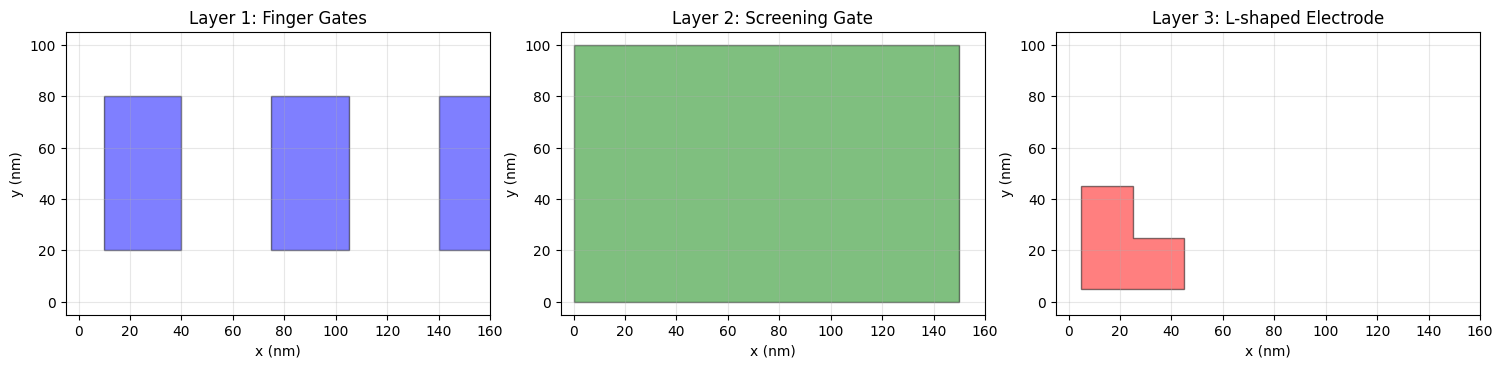

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

layer_names = ["Finger Gates", "Screening Gate", "L-shaped Electrode"]
colors = ["blue", "green", "red"]

for idx, (layer, datatype) in enumerate(layers):
    ax = axes[idx]
    polygons = loader.get_polygons(layer, datatype)
    
    for poly in polygons:
        # Convert to nm for display
        poly_nm = poly * 1e9
        # Close the polygon by repeating the first point
        poly_closed = np.vstack([poly_nm, poly_nm[0]])
        ax.fill(poly_closed[:, 0], poly_closed[:, 1], 
                alpha=0.5, color=colors[idx], edgecolor='black', linewidth=1)
    
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_title(f"Layer {layer}: {layer_names[idx]}")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 160)
    ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

### 2.2 Rasterize Layers to Grid

Convert the vector polygons to a rasterized grid mask.

Grid size: 150 x 100 points
Layer 1: 4012 grid points, ~4012.0 nm² area
Layer 2: 14751 grid points, ~14751.0 nm² area
Layer 3: 1121 grid points, ~1121.0 nm² area


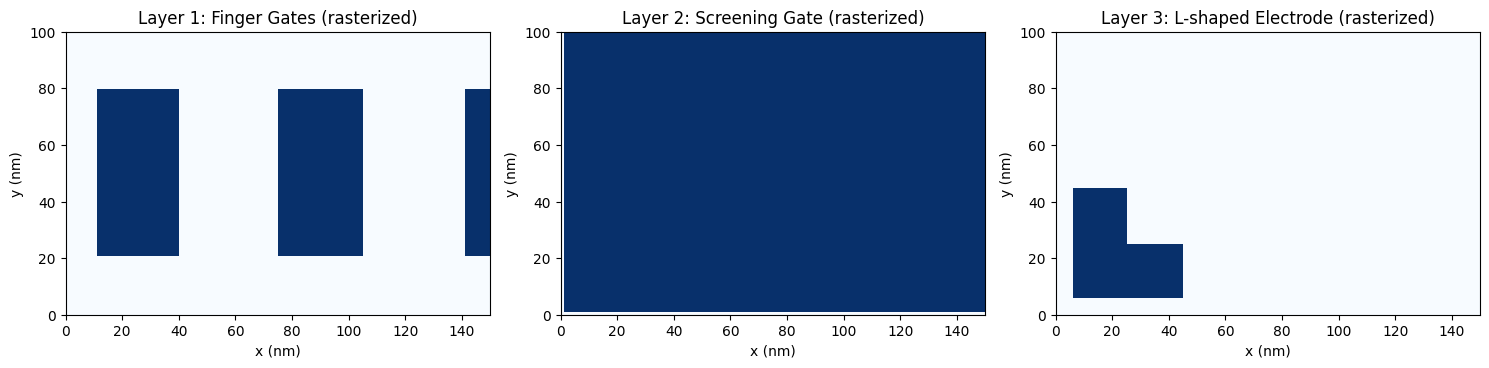

In [5]:
# Define a grid (150nm x 100nm with 1nm spacing)
grid_spacing = 1e-9  # 1 nm
x_coords = np.arange(0, 150e-9, grid_spacing)
y_coords = np.arange(0, 100e-9, grid_spacing)

print(f"Grid size: {len(x_coords)} x {len(y_coords)} points")

# Rasterize each layer
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (layer, datatype) in enumerate(layers):
    ax = axes[idx]
    
    # Rasterize the layer
    mask = loader.rasterize_layer(layer, datatype, x_coords, y_coords)
    
    # Plot as image
    extent = [0, 150, 0, 100]  # in nm
    ax.imshow(mask.T, origin='lower', extent=extent, 
              cmap='Blues', aspect='equal', interpolation='nearest')
    
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_title(f"Layer {layer}: {layer_names[idx]} (rasterized)")
    
    # Count electrode pixels
    electrode_area = mask.sum() * (grid_spacing * 1e9)**2
    print(f"Layer {layer}: {mask.sum()} grid points, ~{electrode_area:.1f} nm² area")

plt.tight_layout()
plt.show()

## Part 3: YAML Configuration for GDS Electrodes

Now let's create a YAML configuration file that uses the GDS file for electrode definitions.

In [6]:
import yaml

# Create configuration dictionary
config = {
    "domain": {
        "size": [150e-9, 100e-9, 50e-9],  # 150nm x 100nm x 50nm
        "grid_spacing": 1e-9  # 1nm isotropic grid
    },
    "layers": [
        {
            "name": "SiO2_layer",
            "material": "SiO2",
            "z_range": [0, -20e-9]  # Surface to -20nm
        },
        {
            "name": "Si_layer",
            "material": "Si",
            "z_range": [-20e-9, -50e-9]  # -20nm to -50nm
        }
    ],
    "electrodes": [
        {
            "source": "gds",
            "gds_file": "tutorial_electrodes.gds",  # Relative to YAML file
            "gds_unit": 1e-6,  # GDS uses micrometers
            "origin": [0, 0],
            "cell_name": None,  # Auto-select top-level cell
            "layer_mapping": [
                {
                    "layer": 1,
                    "datatype": 0,
                    "name": "finger_gates",
                    "voltage": 0.5,
                    "z_position": -10e-9  # 10nm thick electrodes
                },
                {
                    "layer": 3,
                    "datatype": 0,
                    "name": "l_electrode",
                    "voltage": -0.3,
                    "z_position": -10e-9
                }
            ]
        },
        # You can also mix GDS and rectangle electrodes
        {
            "name": "back_gate",
            "shape": "rectangle",
            "x_range": [120e-9, 145e-9],
            "y_range": [10e-9, 90e-9],
            "z_position": -10e-9,
            "voltage": 0.2
        }
    ],
    "boundary_conditions": {
        "z_top": {"type": "neumann", "value": 0.0},
        "z_bottom": {"type": "dirichlet", "value": 0.0},
        "x_sides": {"type": "neumann", "value": 0.0},
        "y_sides": {"type": "neumann", "value": 0.0}
    }
}

# Save to YAML file
yaml_path = output_dir / "gds_example.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"YAML configuration saved to: {yaml_path}")
print("\n" + "=" * 60)
print("Configuration content:")
print("=" * 60)
with open(yaml_path, 'r') as f:
    print(f.read())

YAML configuration saved to: c:\Users\hideb\OneDrive\python-AkiPC\phD\SOR\work\gds_example.yaml

Configuration content:
domain:
  size:
  - 1.5e-07
  - 1.0e-07
  - 5.0e-08
  grid_spacing: 1.0e-09
layers:
- name: SiO2_layer
  material: SiO2
  z_range:
  - 0
  - -2.0e-08
- name: Si_layer
  material: Si
  z_range:
  - -2.0e-08
  - -5.0e-08
electrodes:
- source: gds
  gds_file: tutorial_electrodes.gds
  gds_unit: 1.0e-06
  origin:
  - 0
  - 0
  cell_name: null
  layer_mapping:
  - layer: 1
    datatype: 0
    name: finger_gates
    voltage: 0.5
    z_position: -1.0e-08
  - layer: 3
    datatype: 0
    name: l_electrode
    voltage: -0.3
    z_position: -1.0e-08
- name: back_gate
  shape: rectangle
  x_range:
  - 1.2e-07
  - 1.45e-07
  y_range:
  - 1.0e-08
  - 9.0e-08
  z_position: -1.0e-08
  voltage: 0.2
boundary_conditions:
  z_top:
    type: neumann
    value: 0.0
  z_bottom:
    type: dirichlet
    value: 0.0
  x_sides:
    type: neumann
    value: 0.0
  y_sides:
    type: neumann
    v

## Part 4: Loading and Visualizing GDS Electrodes

Load the configuration with `StructureManager` and visualize the electrode mask.

In [7]:
from structure import StructureManager

# Load the structure
manager = StructureManager(str(yaml_path))

print("Structure loaded successfully!")
print("\n" + manager.get_summary())

Structure loaded successfully!

=== Structure Summary ===
Grid size (nz, nx, ny): (50, 150, 100)
Grid spacing (h): 1.00 nm (isotropic)
Number of layers: 2
Number of electrodes: 2

--- Unique Materials ---
  0. SiO2: εr=3.90, χ=0.900 eV, Eg=9.000 eV
  1. Si: εr=11.70, χ=4.050 eV, Eg=1.120 eV

--- Layers ---
  1. SiO2: z=[0.0, -20.0] nm
  2. Si: z=[-20.0, -50.0] nm

--- Electrodes ---
  1. electrode_1: V=0.000 V, shape=rectangle
  2. back_gate: V=0.200 V, shape=rectangle


### 4.1 Visualize Electrode Mask at Surface

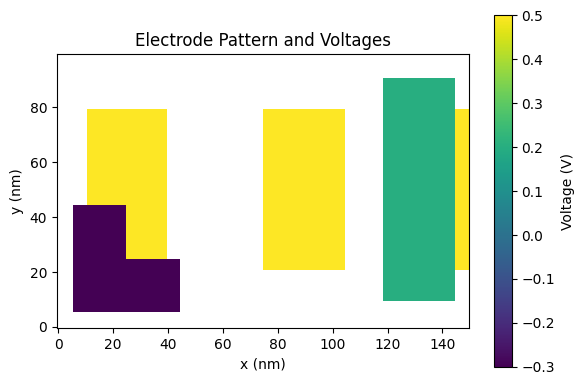

In [9]:
import visualizer as vis

# Get coordinates
x, y, z = manager.get_grid_coordinates()

# Plot electrode pattern at surface (z_index=0)
vis.plot_electrode_pattern(
    electrode_mask=manager.electrode_mask,
    electrode_voltages=manager.electrode_voltages,
    x=x,
    y=y,
    z_index=0,
)

### 4.2 Visualize Electrode Mask in 3D Cross-section

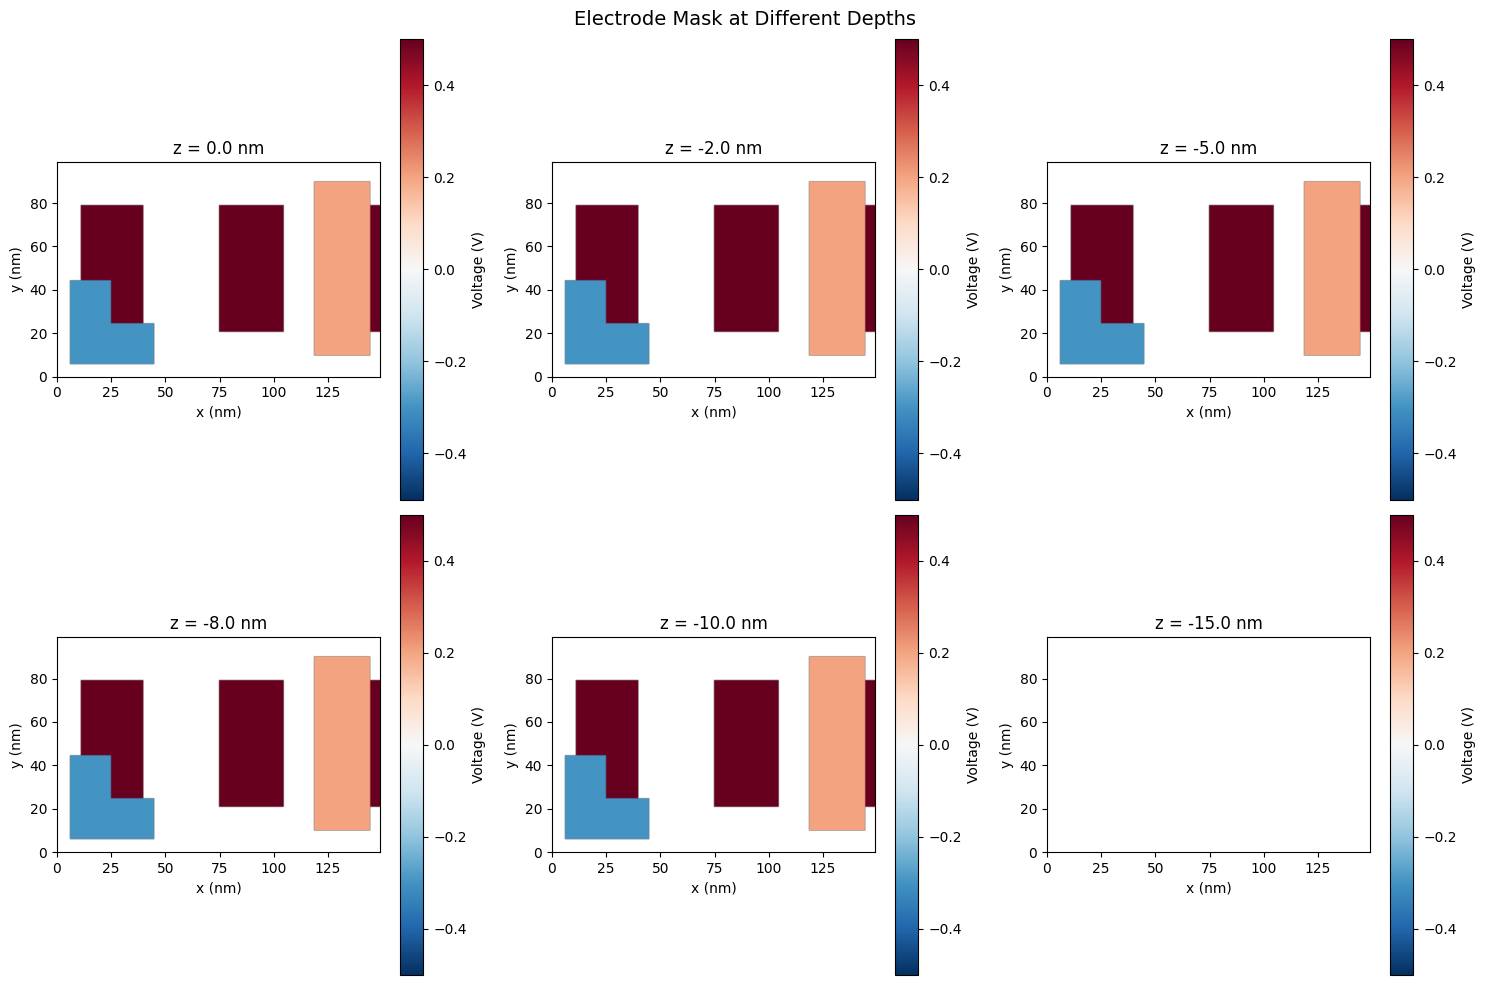

In [10]:
# Plot electrode mask at different z levels
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

z_indices = [0, 2, 5, 8, 10, 15]  # Different depths

for idx, z_idx in enumerate(z_indices):
    ax = axes[idx // 3, idx % 3]
    
    mask_slice = manager.electrode_mask[z_idx, :, :]
    voltage_slice = manager.electrode_voltages[z_idx, :, :]
    
    # Create colored image: show voltage where electrode exists
    display = np.where(mask_slice, voltage_slice, np.nan)
    
    im = ax.imshow(
        display.T,
        origin='lower',
        extent=[x.min()*1e9, x.max()*1e9, y.min()*1e9, y.max()*1e9],
        cmap='RdBu_r',
        vmin=-0.5,
        vmax=0.5,
        aspect='equal'
    )
    
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_title(f"z = {z[z_idx]*1e9:.1f} nm")
    plt.colorbar(im, ax=ax, label="Voltage (V)")

plt.suptitle("Electrode Mask at Different Depths", fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Visualize x-z Cross-section

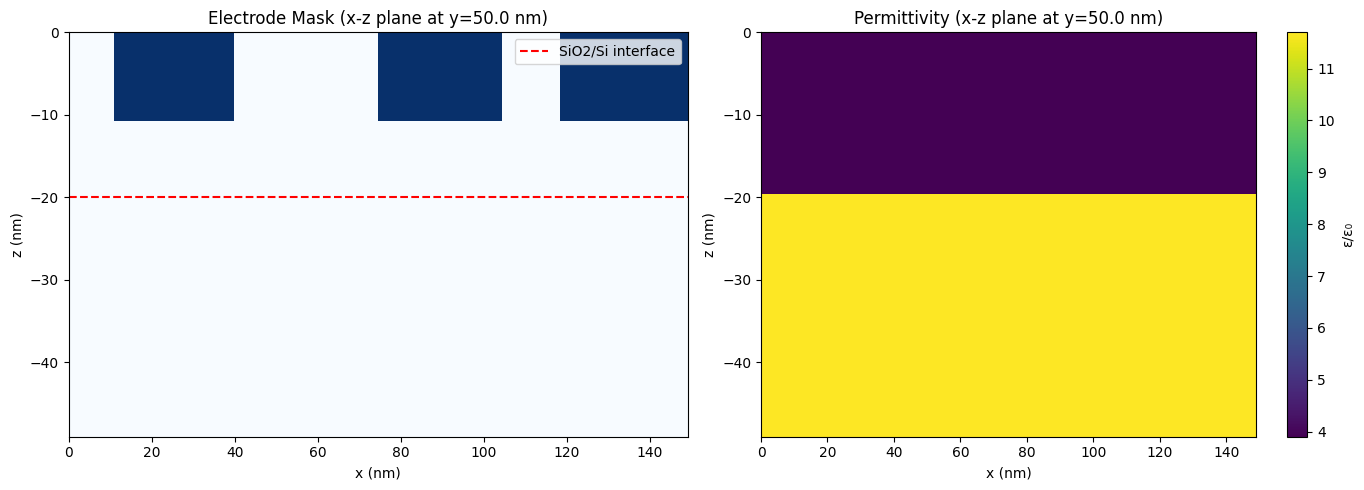

In [11]:
# Plot x-z cross-section through the center of y
y_center = len(y) // 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Electrode mask cross-section
ax1 = axes[0]
mask_xz = manager.electrode_mask[:, :, y_center]
ax1.imshow(
    mask_xz,
    origin='upper',
    extent=[x.min()*1e9, x.max()*1e9, z.min()*1e9, z.max()*1e9],
    cmap='Blues',
    aspect='auto'
)
ax1.set_xlabel("x (nm)")
ax1.set_ylabel("z (nm)")
ax1.set_title(f"Electrode Mask (x-z plane at y={y[y_center]*1e9:.1f} nm)")
ax1.axhline(-20, color='red', linestyle='--', label='SiO2/Si interface')
ax1.legend()

# Permittivity cross-section
ax2 = axes[1]
epsilon_xz = manager.epsilon_array[:, :, y_center]
im = ax2.imshow(
    epsilon_xz,
    origin='upper',
    extent=[x.min()*1e9, x.max()*1e9, z.min()*1e9, z.max()*1e9],
    cmap='viridis',
    aspect='auto'
)
ax2.set_xlabel("x (nm)")
ax2.set_ylabel("z (nm)")
ax2.set_title(f"Permittivity (x-z plane at y={y[y_center]*1e9:.1f} nm)")
plt.colorbar(im, ax=ax2, label="ε/ε₀")

plt.tight_layout()
plt.show()

## Part 5: Running the Poisson Solver

Now solve the Poisson equation with the GDS-defined electrodes.

In [ ]:
from poisson import PoissonSolver

# Initialize solver
solver = PoissonSolver(
    manager,
    omega=1.8,
    tolerance=1e-6,
    max_iterations=10000,
    method="redblack"  # Use parallel Red-Black SOR
)

print("Solver initialized.")
print(f"Grid size: {manager.nz} x {manager.nx} x {manager.ny}")
print(f"Total grid points: {manager.nz * manager.nx * manager.ny:,}")

In [ ]:
# Solve the Poisson equation
print("Solving Poisson equation...")
result = solver.solve(verbose=True)

print("\n" + "=" * 60)
print("Results:")
print("=" * 60)
print(f"Converged: {result.info['converged']}")
print(f"Iterations: {result.info['iterations']}")
print(f"Final Δφ: {result.info['final_phi_change']:.2e}")
print(f"Potential range: [{result.phi.min():.4f}, {result.phi.max():.4f}] V")

### 5.1 Visualize Potential Distribution

In [ ]:
# Plot potential at different z levels
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

z_indices = [0, 5, 10, 15, 20, 30]  # Different depths

for idx, z_idx in enumerate(z_indices):
    ax = axes[idx // 3, idx % 3]
    
    phi_slice = result.phi[z_idx, :, :]
    
    im = ax.imshow(
        phi_slice.T,
        origin='lower',
        extent=[x.min()*1e9, x.max()*1e9, y.min()*1e9, y.max()*1e9],
        cmap='RdBu_r',
        vmin=-0.5,
        vmax=0.5,
        aspect='equal'
    )
    
    # Overlay electrode outline
    mask_slice = manager.electrode_mask[z_idx, :, :]
    ax.contour(
        x * 1e9, y * 1e9, mask_slice.T,
        levels=[0.5], colors='black', linewidths=0.5
    )
    
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_title(f"z = {z[z_idx]*1e9:.1f} nm")
    plt.colorbar(im, ax=ax, label="Potential (V)")

plt.suptitle("Potential Distribution at Different Depths", fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Potential at Si/SiO2 Interface

In [ ]:
# Plot potential at Si/SiO2 interface (z = -20nm)
interface_z = 20  # Index for z = -20nm

vis.plot_potential_slice(
    phi=result.phi,
    x=x,
    y=y,
    z=z,
    z_index=interface_z,
    electrode_mask=manager.electrode_mask,
    title=f"Potential at Si/SiO₂ Interface (z = {z[interface_z]*1e9:.1f} nm)"
)
plt.show()

### 5.3 Band Diagram

In [ ]:
# Plot 1D band diagram at center of finger gate region
# Find x position at center of first finger gate
x_center = int(25e-9 / manager.h)  # Center of first finger gate (~25nm)
y_center = int(50e-9 / manager.h)  # Center in y

vis.plot_band_diagram_1d(
    result=result,
    x_idx=x_center,
    y_idx=y_center,
)
plt.title(f"Band Diagram at (x={x[x_center]*1e9:.0f}nm, y={y[y_center]*1e9:.0f}nm)")
plt.show()

## Summary

This tutorial demonstrated:

1. **Creating GDS files** with gdspy for electrode patterns
2. **Exploring GDS structure** with `GDSLoader`
3. **YAML configuration** for GDS-based electrodes
4. **Visualizing electrode masks** in 2D and 3D
5. **Running Poisson solver** with GDS electrodes

### Key Points

- GDS files use micrometers (um) by default; set `gds_unit=1e-6` to convert to meters
- `layer_mapping` connects GDS layers to electrode properties (voltage, z_position)
- GDS and rectangle electrodes can be mixed in the same configuration
- The `origin` parameter allows shifting GDS patterns to align with the simulation domain

### Next Steps

- Import real device layouts from your design tools
- Use multiple GDS files for different electrode layers
- Combine with `PotentialInterpolator` for fast voltage sweeps